# Future Failure prediction using the Random Forest model

In [1]:
import numpy as np
import pandas as pd

In [2]:
atm = pd.read_csv(r'Dataset/ATM_Maintenance_Cleaned.csv', parse_dates=['Date'])
atm

,Date,ATM_ID,District,Location_Type,Manufacturer,ATM_Age_Yrs,Daily_Transactions,Failed_Transactions,Cash_Remaining_Pct,Cash_Loaded_Today,...,Memory_Usage_Pct,Network_Latency_ms,Network_Drops,UPS_Battery_Pct,Power_Outages_7D,Days_Since_Maintenance,Previous_Failures_90D,Customer_Complaints_7D,Failure_Code,Failure_Next_48H
0,2025-01-01,ATM058,Idukki,Hospital,NCR,1.2,429,15,69.0,0,...,52,46,0,78,2,29,4,1,5,1
1,2025-01-02,ATM173,Kozhikode,Railway,Diebold,1.9,343,6,43.0,0,...,45,10,0,92,3,58,1,0,2,1
2,2025-01-03,ATM187,Malappuram,Airport,Diebold,2.5,285,10,78.0,0,...,53,66,2,88,0,63,0,0,0,0
3,2025-01-04,ATM256,Alappuzha,Rural,Diebold,4.6,488,22,39.0,0,...,67,95,1,68,1,54,0,0,5,1
4,2025-01-05,ATM284,Thrissur,Hospital,NCR,8.7,736,25,57.0,0,...,54,56,3,97,4,57,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2025-12-22,ATM153,Kottayam,Airport,Diebold,8.1,595,29,69.0,0,...,58,177,0,79,3,5,0,0,1,1
49996,2025-12-23,ATM229,Kollam,Airport,Hitachi,7.3,578,11,85.0,1,...,67,41,3,77,3,70,6,1,0,0
49997,2025-12-24,ATM247,Thrissur,Hospital,Diebold,6.2,656,1,35.0,0,...,65,64,0,89,0,43,4,2,0,0
49998,2025-12-25,ATM184,Kottayam,Railway,NCR,1.9,471,19,62.0,0,...,71,114,0,100,1,0,2,3,1,1


In [3]:
atm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    50000 non-null  datetime64[ns]
 1   ATM_ID                  50000 non-null  object        
 2   District                50000 non-null  object        
 3   Location_Type           50000 non-null  object        
 4   Manufacturer            50000 non-null  object        
 5   ATM_Age_Yrs             50000 non-null  float64       
 6   Daily_Transactions      50000 non-null  int64         
 7   Failed_Transactions     50000 non-null  int64         
 8   Cash_Remaining_Pct      50000 non-null  float64       
 9   Cash_Loaded_Today       50000 non-null  int64         
 10  CardReader_Errors       50000 non-null  int64         
 11  CashDispenser_Errors    50000 non-null  int64         
 12  Cash_Jams               50000 non-null  int64 

In [4]:
from sklearn.preprocessing import LabelEncoder

In [5]:
le = LabelEncoder()

In [6]:
for col in ['District', 'Location_Type', 'Manufacturer']:
    atm[col] = le.fit_transform(atm[col].astype(str))

In [7]:
atm

,Date,ATM_ID,District,Location_Type,Manufacturer,ATM_Age_Yrs,Daily_Transactions,Failed_Transactions,Cash_Remaining_Pct,Cash_Loaded_Today,...,Memory_Usage_Pct,Network_Latency_ms,Network_Drops,UPS_Battery_Pct,Power_Outages_7D,Days_Since_Maintenance,Previous_Failures_90D,Customer_Complaints_7D,Failure_Code,Failure_Next_48H
0,2025-01-01,ATM058,2,2,2,1.2,429,15,69.0,0,...,52,46,0,78,2,29,4,1,5,1
1,2025-01-02,ATM173,6,4,0,1.9,343,6,43.0,0,...,45,10,0,92,3,58,1,0,2,1
2,2025-01-03,ATM187,7,0,0,2.5,285,10,78.0,0,...,53,66,2,88,0,63,0,0,0,0
3,2025-01-04,ATM256,0,5,0,4.6,488,22,39.0,0,...,67,95,1,68,1,54,0,0,5,1
4,2025-01-05,ATM284,9,2,2,8.7,736,25,57.0,0,...,54,56,3,97,4,57,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2025-12-22,ATM153,5,0,0,8.1,595,29,69.0,0,...,58,177,0,79,3,5,0,0,1,1
49996,2025-12-23,ATM229,4,0,1,7.3,578,11,85.0,1,...,67,41,3,77,3,70,6,1,0,0
49997,2025-12-24,ATM247,9,2,0,6.2,656,1,35.0,0,...,65,64,0,89,0,43,4,2,0,0
49998,2025-12-25,ATM184,5,4,2,1.9,471,19,62.0,0,...,71,114,0,100,1,0,2,3,1,1


In [8]:
# Sort data chronologically
atm = atm.sort_values('Date').reset_index(drop=True)
atm

,Date,ATM_ID,District,Location_Type,Manufacturer,ATM_Age_Yrs,Daily_Transactions,Failed_Transactions,Cash_Remaining_Pct,Cash_Loaded_Today,...,Memory_Usage_Pct,Network_Latency_ms,Network_Drops,UPS_Battery_Pct,Power_Outages_7D,Days_Since_Maintenance,Previous_Failures_90D,Customer_Complaints_7D,Failure_Code,Failure_Next_48H
0,2025-01-01,ATM058,2,2,2,1.2,429,15,69.0,0,...,52,46,0,78,2,29,4,1,5,1
1,2025-01-01,ATM171,4,1,0,4.7,713,19,21.0,0,...,51,14,0,100,2,102,0,0,1,1
2,2025-01-01,ATM198,9,0,1,4.7,461,16,38.0,0,...,56,58,3,97,3,40,0,3,0,0
3,2025-01-01,ATM186,3,5,1,6.0,657,15,70.0,0,...,80,114,0,74,0,64,2,0,0,0
4,2025-01-01,ATM186,3,5,2,1.8,238,5,50.0,1,...,64,103,0,87,0,54,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2025-12-31,ATM150,0,4,2,5.9,497,7,35.0,0,...,62,59,2,89,0,7,0,2,0,0
49996,2025-12-31,ATM117,3,3,2,9.1,273,5,78.0,1,...,61,89,0,92,1,86,1,0,1,1
49997,2025-12-31,ATM297,7,1,1,5.7,212,2,28.0,0,...,75,10,0,88,0,97,2,2,5,1
49998,2025-12-31,ATM293,1,3,0,5.8,692,2,53.0,0,...,49,76,0,90,0,59,0,2,1,1


In [9]:
X = atm.drop(
    columns=[
        'Date',
        'ATM_ID',
        'Failure_Next_48H',
        'Failure_Code'])

y = atm['Failure_Next_48H']

In [10]:
X

,District,Location_Type,Manufacturer,ATM_Age_Yrs,Daily_Transactions,Failed_Transactions,Cash_Remaining_Pct,Cash_Loaded_Today,CardReader_Errors,CashDispenser_Errors,...,CPU_Temp_C,CPU_Usage_Pct,Memory_Usage_Pct,Network_Latency_ms,Network_Drops,UPS_Battery_Pct,Power_Outages_7D,Days_Since_Maintenance,Previous_Failures_90D,Customer_Complaints_7D
0,2,2,2,1.2,429,15,69.0,0,2,3,...,48.0,29,52,46,0,78,2,29,4,1
1,4,1,0,4.7,713,19,21.0,0,1,3,...,44.2,82,51,14,0,100,2,102,0,0
2,9,0,1,4.7,461,16,38.0,0,2,0,...,43.3,54,56,58,3,97,3,40,0,3
3,3,5,1,6.0,657,15,70.0,0,0,1,...,51.5,55,80,114,0,74,0,64,2,0
4,3,5,2,1.8,238,5,50.0,1,1,2,...,40.6,44,64,103,0,87,0,54,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,0,4,2,5.9,497,7,35.0,0,1,0,...,54.9,61,62,59,2,89,0,7,0,2
49996,3,3,2,9.1,273,5,78.0,1,1,3,...,51.3,69,61,89,0,92,1,86,1,0
49997,7,1,1,5.7,212,2,28.0,0,1,0,...,47.1,47,75,10,0,88,0,97,2,2
49998,1,3,0,5.8,692,2,53.0,0,0,3,...,36.2,68,49,76,0,90,0,59,0,2


In [11]:
y

0        1
1        1
2        0
3        0
4        0
        ..
49995    0
49996    1
49997    1
49998    1
49999    0
Name: Failure_Next_48H, Length: 50000, dtype: int64

In [12]:
# Time-based train-test split
split_index = int(len(atm) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

print("\nTraining period:")
print(atm['Date'].iloc[0], "to", atm['Date'].iloc[split_index - 1])

print("\nTesting period:")
print(atm['Date'].iloc[split_index], "to", atm['Date'].iloc[-1])

Training records: 40000
Testing records: 10000

Training period:
2025-01-01 00:00:00 to 2025-10-19 00:00:00

Testing period:
2025-10-19 00:00:00 to 2025-12-31 00:00:00


### What does split_index mean?
- Suppose your dataset has 50,000 records (len(dataset)=50,000).
- By using "split_index = int(50000 * 0.80) = 400000" means;
   - First 40,000 records → Training
   - Last 10,000 records  → Testing
- Since the dataset is already sorted by dates;
   - Older data  -->  80% Training  -->  Model learns from past conditions 
   - Newer data  -->  20% Testing  -->  Model learns from future/later records

In [13]:
X_train

,District,Location_Type,Manufacturer,ATM_Age_Yrs,Daily_Transactions,Failed_Transactions,Cash_Remaining_Pct,Cash_Loaded_Today,CardReader_Errors,CashDispenser_Errors,...,CPU_Temp_C,CPU_Usage_Pct,Memory_Usage_Pct,Network_Latency_ms,Network_Drops,UPS_Battery_Pct,Power_Outages_7D,Days_Since_Maintenance,Previous_Failures_90D,Customer_Complaints_7D
0,2,2,2,1.2,429,15,69.0,0,2,3,...,48.0,29,52,46,0,78,2,29,4,1
1,4,1,0,4.7,713,19,21.0,0,1,3,...,44.2,82,51,14,0,100,2,102,0,0
2,9,0,1,4.7,461,16,38.0,0,2,0,...,43.3,54,56,58,3,97,3,40,0,3
3,3,5,1,6.0,657,15,70.0,0,0,1,...,51.5,55,80,114,0,74,0,64,2,0
4,3,5,2,1.8,238,5,50.0,1,1,2,...,40.6,44,64,103,0,87,0,54,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,3,4,1,9.4,505,13,68.0,1,1,0,...,43.0,56,63,19,4,100,0,31,0,0
39996,2,0,1,6.0,553,9,52.0,0,2,2,...,52.1,36,51,10,0,90,1,67,0,2
39997,9,3,0,5.0,908,40,58.0,0,0,1,...,40.8,60,65,112,0,84,3,38,0,0
39998,8,0,2,7.8,267,12,64.0,1,0,3,...,44.4,54,65,96,5,91,0,60,0,4


In [14]:
X_test

,District,Location_Type,Manufacturer,ATM_Age_Yrs,Daily_Transactions,Failed_Transactions,Cash_Remaining_Pct,Cash_Loaded_Today,CardReader_Errors,CashDispenser_Errors,...,CPU_Temp_C,CPU_Usage_Pct,Memory_Usage_Pct,Network_Latency_ms,Network_Drops,UPS_Battery_Pct,Power_Outages_7D,Days_Since_Maintenance,Previous_Failures_90D,Customer_Complaints_7D
40000,7,1,1,6.7,415,1,36.0,0,0,3,...,46.3,46,72,77,5,76,3,124,1,0
40001,1,1,0,2.2,369,5,77.0,0,2,1,...,52.3,50,73,110,1,88,2,84,0,2
40002,5,5,0,9.4,791,36,42.0,0,2,3,...,52.0,55,49,65,1,89,0,13,0,0
40003,6,5,2,4.5,606,4,38.0,0,2,0,...,42.7,52,76,136,3,92,0,31,0,0
40004,6,5,1,8.5,669,29,40.0,0,0,2,...,49.7,64,51,68,4,91,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,0,4,2,5.9,497,7,35.0,0,1,0,...,54.9,61,62,59,2,89,0,7,0,2
49996,3,3,2,9.1,273,5,78.0,1,1,3,...,51.3,69,61,89,0,92,1,86,1,0
49997,7,1,1,5.7,212,2,28.0,0,1,0,...,47.1,47,75,10,0,88,0,97,2,2
49998,1,3,0,5.8,692,2,53.0,0,0,3,...,36.2,68,49,76,0,90,0,59,0,2


In [15]:
y_train

0        1
1        1
2        0
3        0
4        0
        ..
39995    1
39996    0
39997    0
39998    1
39999    1
Name: Failure_Next_48H, Length: 40000, dtype: int64

In [16]:
y_test

40000    1
40001    0
40002    1
40003    0
40004    0
        ..
49995    0
49996    1
49997    1
49998    1
49999    0
Name: Failure_Next_48H, Length: 10000, dtype: int64

In [17]:
from sklearn.ensemble import RandomForestClassifier

In [18]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced')

- If one class occurs less frequently than another, give more importance to the minority class.
- For example : No failure = 90% and Failure = 10%
- A model could simply predict "No failure" most of the time and still get high accuracy.
- Balanced class weights help prevent that behaviour

In [19]:
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
y_pred = model.predict(X_test)
y_pred

array([1, 0, 1, ..., 1, 1, 0], shape=(10000,))

In [21]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score)

In [22]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [23]:
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=['No Failure', 'Failure']))


Classification Report:
               precision    recall  f1-score   support

  No Failure       1.00      1.00      1.00      5563
     Failure       1.00      1.00      1.00      4437

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



### Model Evaluation
- The Random Forest model was evaluated using a time-based train-test split, where earlier records were used for training and later records were used for testing.
- Accuracy measures the overall proportion of correctly classified ATM records.
- Precision indicates how many ATMs predicted to fail actually failed.
- Recall is particularly important for ATM maintenance because it measures how many of the actual failure cases were successfully detected.
- F1-score provides a balance between precision and recall.
- The model performance should be interpreted based on the results obtained from the unseen, later-period test data.

In [24]:
importances = model.feature_importances_
feature_names = X.columns

In [25]:
importances

array([0.00208089, 0.00162185, 0.00093847, 0.00374719, 0.00433098,
       0.00302864, 0.00381117, 0.00048519, 0.00088423, 0.47057199,
       0.00050736, 0.47465483, 0.00354422, 0.00428532, 0.00358226,
       0.00361091, 0.00597315, 0.00142901, 0.00322918, 0.00130679,
       0.00359596, 0.00141229, 0.00136814])

In [26]:
feature_names

Index(['District', 'Location_Type', 'Manufacturer', 'ATM_Age_Yrs',
       'Daily_Transactions', 'Failed_Transactions', 'Cash_Remaining_Pct',
       'Cash_Loaded_Today', 'CardReader_Errors', 'CashDispenser_Errors',
       'Cash_Jams', 'Printer_Errors', 'Paper_Remaining_Pct', 'CPU_Temp_C',
       'CPU_Usage_Pct', 'Memory_Usage_Pct', 'Network_Latency_ms',
       'Network_Drops', 'UPS_Battery_Pct', 'Power_Outages_7D',
       'Days_Since_Maintenance', 'Previous_Failures_90D',
       'Customer_Complaints_7D'],
      dtype='object')

In [27]:
import matplotlib.pyplot as plt

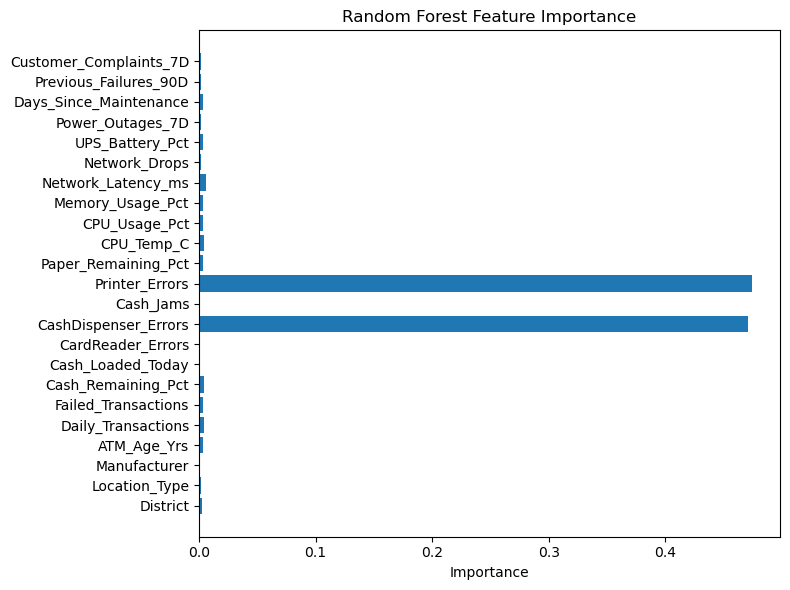

In [28]:
plt.figure(figsize=(8, 6))

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")

plt.barh(feature_names, importances)

plt.tight_layout()
plt.show()

- This graphs shows that , Printer_Errors and CashDispenser_Errors are the most important features for failure prediction.
- All other features have less importance.

# Predicting whether each ATM will fail in the next 48 hours

For the final prediction, the latest available record for each ATM is used as the current condition of that ATM. The trained Random Forest model then predicts whether each ATM is likely to fail within the next 48 hours.

In [29]:
# Get the latest available record for each ATM
latest_atms = (
    atm.sort_values('Date')
       .groupby('ATM_ID')
       .tail(1)
       .reset_index(drop=True))

print("Total unique ATMs:", latest_atms['ATM_ID'].nunique())

latest_atms

Total unique ATMs: 300


,Date,ATM_ID,District,Location_Type,Manufacturer,ATM_Age_Yrs,Daily_Transactions,Failed_Transactions,Cash_Remaining_Pct,Cash_Loaded_Today,...,Memory_Usage_Pct,Network_Latency_ms,Network_Drops,UPS_Battery_Pct,Power_Outages_7D,Days_Since_Maintenance,Previous_Failures_90D,Customer_Complaints_7D,Failure_Code,Failure_Next_48H
0,2025-12-16,ATM162,6,1,2,9.9,639,13,81.0,0,...,54,87,0,100,1,44,0,4,5,1
1,2025-12-18,ATM277,2,0,0,2.7,459,0,25.0,0,...,65,77,0,76,0,37,1,0,3,1
2,2025-12-21,ATM216,8,0,1,3.2,352,11,72.0,0,...,52,45,3,100,0,51,4,0,0,0
3,2025-12-21,ATM267,7,1,1,3.2,220,7,57.0,0,...,62,127,0,91,0,0,0,1,6,1
4,2025-12-21,ATM252,7,0,0,1.2,413,16,14.0,0,...,60,59,3,100,2,50,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,2025-12-31,ATM231,6,1,2,8.9,423,7,67.0,0,...,48,69,0,81,0,63,1,0,0,0
296,2025-12-31,ATM097,2,1,1,9.4,429,12,58.0,1,...,53,52,1,90,0,40,1,0,0,0
297,2025-12-31,ATM041,2,2,1,9.8,687,30,57.0,1,...,58,10,0,83,1,40,5,0,0,0
298,2025-12-31,ATM210,5,4,0,2.9,453,19,62.0,0,...,69,77,0,86,0,47,0,1,0,0


- In our dataset most ATM's have more than 1 records.
- We don't need to predict for all recoreds of the same ATM.
- We only need to predict the latest condition of each ATM.
- So we use "groupby(ATM_ID)" : groups the records belonging to each ATM.
- Then use "tail(1)" : takes the last/latest record for each ATM.
    - Historical ATM records --> Group by ATM_ID --> Take latest record --> One record per ATM

In [30]:
# Prepare features for the latest ATM records

X_latest = latest_atms.drop(
    columns=[
        'Date',
        'ATM_ID',
        'Failure_Next_48H',
        'Failure_Code'])

X_latest

,District,Location_Type,Manufacturer,ATM_Age_Yrs,Daily_Transactions,Failed_Transactions,Cash_Remaining_Pct,Cash_Loaded_Today,CardReader_Errors,CashDispenser_Errors,...,CPU_Temp_C,CPU_Usage_Pct,Memory_Usage_Pct,Network_Latency_ms,Network_Drops,UPS_Battery_Pct,Power_Outages_7D,Days_Since_Maintenance,Previous_Failures_90D,Customer_Complaints_7D
0,6,1,2,9.9,639,13,81.0,0,1,0,...,52.5,53,54,87,0,100,1,44,0,4
1,2,0,0,2.7,459,0,25.0,0,0,3,...,45.5,58,65,77,0,76,0,37,1,0
2,8,0,1,3.2,352,11,72.0,0,2,1,...,48.2,55,52,45,3,100,0,51,4,0
3,7,1,1,3.2,220,7,57.0,0,1,3,...,42.7,21,62,127,0,91,0,0,0,1
4,7,0,0,1.2,413,16,14.0,0,0,3,...,43.5,41,60,59,3,100,2,50,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,6,1,2,8.9,423,7,67.0,0,2,0,...,40.3,12,48,69,0,81,0,63,1,0
296,2,1,1,9.4,429,12,58.0,1,0,1,...,49.1,53,53,52,1,90,0,40,1,0
297,2,2,1,9.8,687,30,57.0,1,0,1,...,51.4,47,58,10,0,83,1,40,5,0
298,5,4,0,2.9,453,19,62.0,0,1,0,...,50.4,78,69,77,0,86,0,47,0,1


In [31]:
# Predict failure for each ATM

latest_predictions = model.predict(X_latest)

latest_atms['Predicted_Failure_Next_48H'] = latest_predictions

latest_atms

,Date,ATM_ID,District,Location_Type,Manufacturer,ATM_Age_Yrs,Daily_Transactions,Failed_Transactions,Cash_Remaining_Pct,Cash_Loaded_Today,...,Network_Latency_ms,Network_Drops,UPS_Battery_Pct,Power_Outages_7D,Days_Since_Maintenance,Previous_Failures_90D,Customer_Complaints_7D,Failure_Code,Failure_Next_48H,Predicted_Failure_Next_48H
0,2025-12-16,ATM162,6,1,2,9.9,639,13,81.0,0,...,87,0,100,1,44,0,4,5,1,1
1,2025-12-18,ATM277,2,0,0,2.7,459,0,25.0,0,...,77,0,76,0,37,1,0,3,1,1
2,2025-12-21,ATM216,8,0,1,3.2,352,11,72.0,0,...,45,3,100,0,51,4,0,0,0,0
3,2025-12-21,ATM267,7,1,1,3.2,220,7,57.0,0,...,127,0,91,0,0,0,1,6,1,1
4,2025-12-21,ATM252,7,0,0,1.2,413,16,14.0,0,...,59,3,100,2,50,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,2025-12-31,ATM231,6,1,2,8.9,423,7,67.0,0,...,69,0,81,0,63,1,0,0,0,0
296,2025-12-31,ATM097,2,1,1,9.4,429,12,58.0,1,...,52,1,90,0,40,1,0,0,0,0
297,2025-12-31,ATM041,2,2,1,9.8,687,30,57.0,1,...,10,0,83,1,40,5,0,0,0,0
298,2025-12-31,ATM210,5,4,0,2.9,453,19,62.0,0,...,77,0,86,0,47,0,1,0,0,0


In [32]:
# Probability that each ATM will fail within the next 48 hours

failure_probability = model.predict_proba(X_latest)[:, 1]

latest_atms['Failure_Probability'] = failure_probability

latest_atms['Failure_Probability'] = (latest_atms['Failure_Probability'] * 100).round(2)

latest_atms

,Date,ATM_ID,District,Location_Type,Manufacturer,ATM_Age_Yrs,Daily_Transactions,Failed_Transactions,Cash_Remaining_Pct,Cash_Loaded_Today,...,Network_Drops,UPS_Battery_Pct,Power_Outages_7D,Days_Since_Maintenance,Previous_Failures_90D,Customer_Complaints_7D,Failure_Code,Failure_Next_48H,Predicted_Failure_Next_48H,Failure_Probability
0,2025-12-16,ATM162,6,1,2,9.9,639,13,81.0,0,...,0,100,1,44,0,4,5,1,1,95.0
1,2025-12-18,ATM277,2,0,0,2.7,459,0,25.0,0,...,0,76,0,37,1,0,3,1,1,100.0
2,2025-12-21,ATM216,8,0,1,3.2,352,11,72.0,0,...,3,100,0,51,4,0,0,0,0,2.0
3,2025-12-21,ATM267,7,1,1,3.2,220,7,57.0,0,...,0,91,0,0,0,1,6,1,1,100.0
4,2025-12-21,ATM252,7,0,0,1.2,413,16,14.0,0,...,3,100,2,50,1,1,1,1,1,99.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,2025-12-31,ATM231,6,1,2,8.9,423,7,67.0,0,...,0,81,0,63,1,0,0,0,0,1.0
296,2025-12-31,ATM097,2,1,1,9.4,429,12,58.0,1,...,1,90,0,40,1,0,0,0,0,1.0
297,2025-12-31,ATM041,2,2,1,9.8,687,30,57.0,1,...,0,83,1,40,5,0,0,0,0,3.0
298,2025-12-31,ATM210,5,4,0,2.9,453,19,62.0,0,...,0,86,0,47,0,1,0,0,0,1.0


## 1. Extract ATM's Predicted to fail

In [33]:
failing_atms = latest_atms[
    latest_atms['Predicted_Failure_Next_48H'] == 1].sort_values(by='Failure_Probability', ascending=False)

failing_atms

,Date,ATM_ID,District,Location_Type,Manufacturer,ATM_Age_Yrs,Daily_Transactions,Failed_Transactions,Cash_Remaining_Pct,Cash_Loaded_Today,...,Network_Drops,UPS_Battery_Pct,Power_Outages_7D,Days_Since_Maintenance,Previous_Failures_90D,Customer_Complaints_7D,Failure_Code,Failure_Next_48H,Predicted_Failure_Next_48H,Failure_Probability
215,2025-12-31,ATM193,2,5,2,9.0,299,1,58.0,0,...,2,84,0,30,0,0,6,1,1,100.0
101,2025-12-29,ATM019,9,3,0,6.6,571,12,35.0,0,...,4,93,1,56,0,0,3,1,1,100.0
102,2025-12-29,ATM109,7,5,1,6.6,626,5,50.0,0,...,1,89,2,54,0,0,5,1,1,100.0
47,2025-12-27,ATM108,0,5,0,3.4,378,1,61.0,0,...,3,85,0,50,1,1,3,1,1,100.0
52,2025-12-28,ATM208,0,3,2,6.0,341,11,59.0,0,...,1,85,0,29,0,1,6,1,1,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34,2025-12-27,ATM190,8,2,0,2.2,301,10,45.0,0,...,2,90,2,4,0,0,5,1,1,94.0
223,2025-12-31,ATM029,2,0,1,3.0,749,22,17.0,0,...,0,78,0,0,0,0,2,1,1,94.0
141,2025-12-30,ATM028,3,2,2,7.3,597,13,46.0,1,...,3,100,4,1,0,1,6,1,1,94.0
15,2025-12-25,ATM070,3,2,0,9.9,618,11,56.0,0,...,0,150,0,0,2,2,3,1,1,93.0


In [34]:
failing_atms[['ATM_ID',
              'Date',
              'ATM_Age_Yrs',
              'CashDispenser_Errors',
              'Printer_Errors',
              'Days_Since_Maintenance',
              'Failure_Probability',
              'Predicted_Failure_Next_48H']]

,ATM_ID,Date,ATM_Age_Yrs,CashDispenser_Errors,Printer_Errors,Days_Since_Maintenance,Failure_Probability,Predicted_Failure_Next_48H
215,ATM193,2025-12-31,9.0,3,2,30,100.0,1
101,ATM019,2025-12-29,6.6,3,3,56,100.0,1
102,ATM109,2025-12-29,6.6,3,1,54,100.0,1
47,ATM108,2025-12-27,3.4,3,1,50,100.0,1
52,ATM208,2025-12-28,6.0,3,3,29,100.0,1
...,...,...,...,...,...,...,...,...
34,ATM190,2025-12-27,2.2,0,3,4,94.0,1
223,ATM029,2025-12-31,3.0,2,3,0,94.0,1
141,ATM028,2025-12-30,7.3,1,3,1,94.0,1
15,ATM070,2025-12-25,9.9,1,3,0,93.0,1


## 2. Extract ATMs predicted NOT to fail

In [35]:
non_failing_atms = latest_atms[
    latest_atms['Predicted_Failure_Next_48H'] == 0
].sort_values(
    by='Failure_Probability',
    ascending=True
)

non_failing_atms

,Date,ATM_ID,District,Location_Type,Manufacturer,ATM_Age_Yrs,Daily_Transactions,Failed_Transactions,Cash_Remaining_Pct,Cash_Loaded_Today,...,Network_Drops,UPS_Battery_Pct,Power_Outages_7D,Days_Since_Maintenance,Previous_Failures_90D,Customer_Complaints_7D,Failure_Code,Failure_Next_48H,Predicted_Failure_Next_48H,Failure_Probability
157,2025-12-30,ATM141,6,5,1,1.8,602,14,59.0,0,...,2,83,0,51,0,0,0,0,0,0.0
59,2025-12-28,ATM212,5,2,1,5.7,576,21,77.0,0,...,0,96,2,42,0,0,0,0,0,0.0
60,2025-12-28,ATM152,9,1,0,9.6,461,18,51.0,0,...,0,86,2,5,2,1,0,0,0,0.0
63,2025-12-28,ATM035,1,2,0,2.4,462,9,28.0,1,...,2,95,0,6,1,3,0,0,0,0.0
243,2025-12-31,ATM253,7,0,1,4.5,233,3,99.0,0,...,0,83,2,28,1,1,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246,2025-12-31,ATM140,3,3,0,5.3,265,10,77.0,1,...,3,93,0,32,2,1,0,0,0,5.0
231,2025-12-31,ATM205,6,0,1,5.8,98,3,41.0,0,...,1,93,6,25,2,1,0,0,0,5.0
263,2025-12-31,ATM282,2,0,0,7.7,507,18,70.0,0,...,4,56,0,7,1,0,0,0,0,6.0
17,2025-12-25,ATM298,1,1,0,3.2,429,2,73.0,1,...,2,78,0,40,0,4,0,0,0,6.0


In [36]:
non_failing_atms[
    [
        'ATM_ID',
        'Date',
        'ATM_Age_Yrs',
        'CashDispenser_Errors',
        'Printer_Errors',
        'Days_Since_Maintenance',
        'Failure_Probability',
        'Predicted_Failure_Next_48H']]

,ATM_ID,Date,ATM_Age_Yrs,CashDispenser_Errors,Printer_Errors,Days_Since_Maintenance,Failure_Probability,Predicted_Failure_Next_48H
157,ATM141,2025-12-30,1.8,0,2,51,0.0,0
59,ATM212,2025-12-28,5.7,1,2,42,0.0,0
60,ATM152,2025-12-28,9.6,2,0,5,0.0,0
63,ATM035,2025-12-28,2.4,1,1,6,0.0,0
243,ATM253,2025-12-31,4.5,1,2,28,0.0,0
...,...,...,...,...,...,...,...,...
246,ATM140,2025-12-31,5.3,1,1,32,5.0,0
231,ATM205,2025-12-31,5.8,1,1,25,5.0,0
263,ATM282,2025-12-31,7.7,2,0,7,6.0,0
17,ATM298,2025-12-25,3.2,2,2,40,6.0,0


In [37]:
print("Total unique ATMs:", len(latest_atms))

print(
    "ATMs predicted to fail in the next 48 hours:",
    len(failing_atms)
)

print(
    "ATMs predicted not to fail in the next 48 hours:",
    len(non_failing_atms)
)

Total unique ATMs: 300
ATMs predicted to fail in the next 48 hours: 139
ATMs predicted not to fail in the next 48 hours: 161


In [38]:
latest_atms = latest_atms.sort_values(
    by='Failure_Probability',
    ascending=False
)

latest_atms[
    [
        'ATM_ID',
        'Date',
        'Failure_Probability',
        'Predicted_Failure_Next_48H'
    ]
]

,ATM_ID,Date,Failure_Probability,Predicted_Failure_Next_48H
195,ATM125,2025-12-30,100.0,1
21,ATM221,2025-12-26,100.0,1
25,ATM223,2025-12-26,100.0,1
215,ATM193,2025-12-31,100.0,1
81,ATM080,2025-12-28,100.0,1
...,...,...,...,...
237,ATM242,2025-12-31,0.0,0
239,ATM287,2025-12-31,0.0,0
243,ATM253,2025-12-31,0.0,0
33,ATM052,2025-12-27,0.0,0


In [39]:
# Save predicted failing and non-failing ATMs

failing_atms.to_csv(r'Dataset/Predicted_Failing_ATMs.csv',index=False)

non_failing_atms.to_csv(r'Dataset/Predicted_Non_Failing_ATMs.csv',index=False)

latest_atms.to_csv(r'Dataset/All_ATM_Predictions.csv',index=False)

print("Prediction files saved successfully.")

Prediction files saved successfully.
